# Practical 3: Classification

| Prac No | Practical Description 
|---|---|
| 3 (a) | Implement categorical classification
| 3 (b) | Implement logistic regression
| 3 (c) | Implement k-Nearest Neighbors (k-NN)
| 3 (d) | Implement Support Vector Machines (SVM)

## Setup — imports and global configuration

In [1]:
import numpy as np, pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, make_moons, make_blobs
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)
warnings.filterwarnings('ignore')
pd.set_option('display.width', 100)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
RS = 42
np.random.seed(RS)

---
# 3(A) Categorical Classification

### Aim
To study and implement categorical classification, that is, to build and evaluate classification models in which both the input features and the target variable are categorical, and to understand how a multi-class problem is handled and measured.

### Software Used
- Jupyter Notebook (Python 3)
- NumPy, Pandas
- Scikit-learn (OneHotEncoder, OrdinalEncoder, LabelEncoder, CategoricalNB, ColumnTransformer)
- Matplotlib, Seaborn

### Theory
**Classification** is a supervised learning task in which the target variable is a **category** and not a number. The model is given a set of labelled examples and it has to learn a decision rule that assigns every new sample to one of the known classes. When the target is a number the task would be regression; here the output belongs to a finite, unordered set such as {Low, Medium, High}.

Classification problems are of the following kinds:

- **Binary classification:** exactly two classes, e.g. spam / not spam, benign / malignant.

- **Multi-class classification:** more than two classes but every sample belongs to exactly one of them, e.g. Low / Medium / High risk. This is the case implemented here.

- **Multi-label classification:** a sample may belong to several classes at the same time, e.g. one film being both "Comedy" and "Romance".

- **Imbalanced classification:** one class occurs far more often than the others, e.g. fraud detection, where accuracy alone becomes a misleading measure.

**Categorical classification** means that the *data itself* is categorical. Since no algorithm can work on the text "Salaried" or "Tier-2", every categorical column must first be converted into numbers:

- **Nominal features** (no natural order) are given to a **OneHotEncoder**, which creates one 0/1 column per category so that no false order is introduced.

- **Ordinal features** (a real order exists, e.g. High School < Bachelors < Masters < PhD) are given to an **OrdinalEncoder** with the order supplied by the user.

- The **target** column is converted by a **LabelEncoder**, which is the only correct place to use label encoding, because the class numbers are never used in an arithmetic sense.

- A **ColumnTransformer** applies a different encoder to a different group of columns and keeps the whole operation inside one object, and a **Pipeline** guarantees that the encoder is fitted on the training data only.

A multi-class problem is solved by a classifier in one of three ways:

- **Natively**, as in a Decision Tree, Random Forest or Naive Bayes, which can handle any number of classes directly.

- **One-vs-Rest (OvR):** *k* binary models are built, the i-th model learning "class i against all the others". The class whose model gives the highest score wins. It needs only *k* models.

- **One-vs-One (OvO):** one binary model is built for every pair of classes, i.e. *k(k-1)/2* models, and the final class is decided by voting. Each model is trained on a smaller subset, which is why SVM uses this strategy.

A classification model is **never** judged by accuracy alone. The **confusion matrix** records the actual class against the predicted class, and from its four basic quantities — True Positive (TP), True Negative (TN), False Positive (FP) and False Negative (FN) — the standard measures are derived:

- **Accuracy = (TP+TN)/Total** — the overall proportion of correct predictions. It becomes useless when the classes are imbalanced.

- **Precision = TP/(TP+FP)** — of all the samples predicted positive, how many really were. It is used when a false alarm is costly.

- **Recall (Sensitivity) = TP/(TP+FN)** — of all the actual positives, how many were found. It is used when a miss is costly, as in a medical test.

- **F1-score = 2PR/(P+R)** — the harmonic mean of precision and recall, used when both matter.

- For multi-class data these are averaged as **macro** (every class counted equally, so the rare classes matter), **weighted** (each class counted according to its support) or **micro** (all samples pooled together).

---
### Implementation & Result

#### Step 1: The categorical dataset

In [2]:
data = pd.DataFrame({
 'Employment': ['Salaried','Student','Salaried','Self-Employed','Student','Salaried',
                'Retired','Self-Employed','Salaried','Student','Retired','Salaried',
                'Self-Employed','Student','Salaried','Retired','Salaried','Student',
                'Self-Employed','Salaried'],
 'Education' : ['Masters','High School','PhD','Bachelors','Bachelors','Masters',
                'Bachelors','Masters','PhD','High School','High School','Bachelors',
                'PhD','Bachelors','Masters','Masters','Bachelors','High School',
                'Bachelors','PhD'],
 'City'      : ['Tier-1','Tier-2','Tier-1','Tier-3','Tier-2','Tier-1','Tier-3','Tier-2',
                'Tier-1','Tier-3','Tier-2','Tier-1','Tier-2','Tier-3','Tier-1','Tier-2',
                'Tier-3','Tier-2','Tier-1','Tier-1'],
 'OwnsHouse' : ['Yes','No','Yes','No','No','Yes','Yes','No','Yes','No','Yes','No',
                'Yes','No','Yes','Yes','No','No','Yes','Yes'],
 'Risk'      : ['Low','High','Low','Medium','High','Low','Medium','Medium','Low','High',
                'Medium','Medium','Low','High','Low','Medium','Medium','High','Low','Low']})

print('Shape of the dataset :', data.shape)
print(data.head(6).to_string(index=False))
print('\nEvery column is categorical (text), so nothing can be given to a model directly.')
print('\nDistribution of the target :')
print(data['Risk'].value_counts().to_string())

Shape of the dataset : (20, 5)
   Employment   Education   City OwnsHouse   Risk
     Salaried     Masters Tier-1       Yes    Low
      Student High School Tier-2        No   High
     Salaried         PhD Tier-1       Yes    Low
Self-Employed   Bachelors Tier-3        No Medium
      Student   Bachelors Tier-2        No   High
     Salaried     Masters Tier-1       Yes    Low

Every column is categorical (text), so nothing can be given to a model directly.

Distribution of the target :
Risk
Low       8
Medium    7
High      5


#### Step 2: Encoding the categorical features and the target

In [3]:
X = data.drop(columns='Risk')
y_text = data['Risk']

# --- 1. the target is converted by LabelEncoder ---
le = LabelEncoder()
y = le.fit_transform(y_text)
print('Target encoding :', dict(zip(le.classes_, range(len(le.classes_)))))

# --- 2. nominal columns -> OneHotEncoder, ordinal column -> OrdinalEncoder ---
edu_order = ['High School','Bachelors','Masters','PhD']
prep = ColumnTransformer([
    ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                ['Employment','City','OwnsHouse']),
    ('ordinal', OrdinalEncoder(categories=[edu_order]), ['Education'])])

X_enc = prep.fit_transform(X)
names = [c.split('__')[1] for c in prep.get_feature_names_out()]
print('\nColumns : %d  ->  %d after encoding' % (X.shape[1], X_enc.shape[1]))
print(pd.DataFrame(X_enc, columns=names).head(4).astype(int).to_string(index=False))
print('\nEducation became 0/1/2/3 because it has an order (High School < ... < PhD),')
print('while Employment and City became one 0/1 column per category (no order).')

Target encoding : {'High': 0, 'Low': 1, 'Medium': 2}

Columns : 4  ->  10 after encoding
 Employment_Retired  Employment_Salaried  Employment_Self-Employed  Employment_Student  City_Tier-1  City_Tier-2  City_Tier-3  OwnsHouse_No  OwnsHouse_Yes  Education
                  0                    1                         0                   0            1            0            0             0              1          2
                  0                    0                         0                   1            0            1            0             1              0          0
                  0                    1                         0                   0            1            0            0             0              1          3
                  0                    0                         1                   0            0            0            1             1              0          1

Education became 0/1/2/3 because it has an order (High School < ... < PhD),
whil

#### Step 3: Training the classifier and predicting a new sample

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X_enc, y, test_size=.3, random_state=RS, stratify=y)
print('Training samples : %d    Testing samples : %d' % (len(X_tr), len(X_te)))

model = DecisionTreeClassifier(random_state=RS).fit(X_tr, y_tr)
y_pred = model.predict(X_te)

print('\nActual    :', le.inverse_transform(y_te))
print('Predicted :', le.inverse_transform(y_pred))
print('\nAccuracy  : %.4f' % accuracy_score(y_te, y_pred))

print('\nPrediction for a new applicant (Salaried, PhD, Tier-1, OwnsHouse=Yes):')
new = pd.DataFrame([{'Employment':'Salaried','Education':'PhD','City':'Tier-1','OwnsHouse':'Yes'}])
print('  ->', le.inverse_transform(model.predict(prep.transform(new)))[0], 'risk')

Training samples : 14    Testing samples : 6

Actual    : ['High' 'Low' 'High' 'Medium' 'Medium' 'Low']
Predicted : ['High' 'Low' 'High' 'Low' 'Medium' 'Medium']

Accuracy  : 0.6667

Prediction for a new applicant (Salaried, PhD, Tier-1, OwnsHouse=Yes):
  -> Low risk


#### Step 4: Confusion matrix, classification report and comparison of the models

In [5]:
print('Confusion matrix:')
cm = confusion_matrix(y_te, y_pred)
print(pd.DataFrame(cm, index=['Actual '+c for c in le.classes_],
                   columns=['Pred '+c for c in le.classes_]).to_string())
print('\nClassification report:')
print(classification_report(y_te, y_pred, target_names=le.classes_, zero_division=0))

# --- comparing a few classifiers on the same categorical data ---
models = {'Decision Tree': DecisionTreeClassifier(random_state=RS),
          'Categorical NB': CategoricalNB(),
          'Logistic Regression': LogisticRegression(max_iter=1000),
          'k-NN (k=3)': KNeighborsClassifier(3),
          'SVM (RBF)': SVC()}
for name, m in models.items():
    m.fit(X_tr, y_tr)
    print('%-20s accuracy = %.4f' % (name, accuracy_score(y_te, m.predict(X_te))))

Confusion matrix:
               Pred High  Pred Low  Pred Medium
Actual High            2         0            0
Actual Low             0         1            1
Actual Medium          0         1            1

Classification report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         2
         Low       0.50      0.50      0.50         2
      Medium       0.50      0.50      0.50         2

    accuracy                           0.67         6
   macro avg       0.67      0.67      0.67         6
weighted avg       0.67      0.67      0.67         6

Decision Tree        accuracy = 0.6667
Categorical NB       accuracy = 0.6667
Logistic Regression  accuracy = 0.8333
k-NN (k=3)           accuracy = 0.6667
SVM (RBF)            accuracy = 0.8333


### Observations
- The dataset had **20 records, 4 categorical features and a 3-class target** (Low 8, Medium 7, High 5), and no column could be given to a model in its original text form.
- After encoding, the **4 original columns became 10 columns** - Education was converted into a single ordinal column with the values 0, 1, 2, 3 because it has a real order, while Employment, City and OwnsHouse were one-hot encoded into 0/1 columns so that no false order was created.
- The Decision Tree gave an accuracy of **0.6667** on the six test samples, and a new applicant (Salaried, PhD, Tier-1, OwnsHouse = Yes) was correctly predicted as **"Low" risk**.
- The confusion matrix showed that the class **"High" was predicted perfectly (2 of 2)**, while one "Low" and one "Medium" sample were interchanged, which is not visible in the accuracy value alone.
- On the same encoded data, **Logistic Regression and SVM (RBF) gave the best accuracy of 0.8333**, while the Decision Tree, Categorical Naive Bayes and k-NN gave 0.6667 each.

### Conclusion

In conclusion, categorical classification was successfully implemented on a dataset in which all the six input features and the three-class target variable were categorical. It was observed that categorical data must first be encoded correctly — one-hot encoding for the nominal columns, ordinal encoding for the columns having a real order, and label encoding only for the target — and that the whole encoding must be kept inside a Pipeline fitted on the training data alone. It was also observed that a multi-class problem is internally reduced to several binary problems by the One-vs-Rest or One-vs-One strategy, and that the performance of such a model must be judged from the confusion matrix and from precision, recall and F1-score rather than from accuracy, because accuracy hides the failure of the model on the rare classes.

---
# 3(B) Logistic Regression

### Aim
To study and implement logistic regression for classification, to understand the sigmoid function, the log-loss cost function and the effect of regularisation, and to evaluate the model using the confusion matrix, the decision threshold and the ROC curve.

### Software Used
- Jupyter Notebook (Python 3)
- NumPy, Pandas
- Scikit-learn (LogisticRegression, metrics, Pipeline, StandardScaler)
- Matplotlib, Seaborn

### Theory
**Logistic regression** is a supervised learning algorithm used for **classification**, in spite of the word "regression" in its name. A linear regression line cannot be used for a classification problem because its output is unbounded (it can give 2.7 or -0.4, which cannot be a probability) and because a single far-away point tilts the whole line.

Logistic regression solves this by passing the linear combination of the features through the **sigmoid (logistic) function**:

- z = b0 + b1x1 + b2x2 + ... + bnxn
- **s(z) = 1 / (1 + e^-z)**, which always lies between 0 and 1 and can therefore be read as **P(y = 1 | x)**.

Rearranging the same equation gives the **logit**, i.e. **log(p/(1-p)) = z**. Hence logistic regression is a linear model **in the log-odds**: the coefficient b is the change in the log-odds for a unit change in the feature, and **e^b (the odds ratio)** is the factor by which the odds are multiplied. Because z is linear, the **decision boundary is always a straight line (or a hyperplane)**.

The model is fitted by **Maximum Likelihood**, which is equivalent to minimising the **log-loss (binary cross-entropy)**:

- **J(b) = -(1/m) * Σ [ y·log(p) + (1-y)·log(1-p) ]**

The squared error of linear regression is **not** used, because with the sigmoid inside it the cost becomes non-convex and gradient descent can stop at a local minimum. The log-loss is convex, and it punishes a confident wrong answer very heavily since -log(p) tends to infinity as p tends to 0. There is no closed-form solution, so the coefficients are found iteratively by **gradient descent**, whose update rule is remarkably simple:

- **b := b - a * (1/m) * X^T (p - y)**, where a is the learning rate.

**Regularisation** is added to the cost to prevent overfitting:

- **L2 (Ridge)** adds the sum of the squared coefficients. It shrinks all the coefficients smoothly towards zero.
- **L1 (Lasso)** adds the sum of the absolute coefficients. It can make a coefficient **exactly zero**, so it also performs feature selection.
- In scikit-learn the strength is given by **C, which is the inverse of the regularisation strength**: a small C means strong regularisation and a simple model, a large C means an almost unpenalised model.

For **multi-class** problems logistic regression is extended by the **softmax (multinomial)** function, which gives one probability per class such that all of them add up to 1, or by the **One-vs-Rest** strategy.

Since the output is a **probability**, the final class is obtained by comparing it with a **threshold**, which is 0.5 only by default. Lowering the threshold increases recall and lowers precision, and raising it does the opposite. The **ROC curve** plots the true positive rate against the false positive rate for every possible threshold, and the **area under it (AUC)** measures the quality of the model independently of any one threshold (0.5 = random guessing, 1.0 = perfect).

Logistic regression assumes a linear relationship between the features and the log-odds, little multicollinearity and independent observations. It is fast, and its coefficients can be interpreted, which is why it is the standard baseline model for every classification problem. Feature scaling is required because the solver uses gradients and the penalty term treats all the coefficients equally.

---
### Implementation & Result

#### Step 1: The sigmoid function

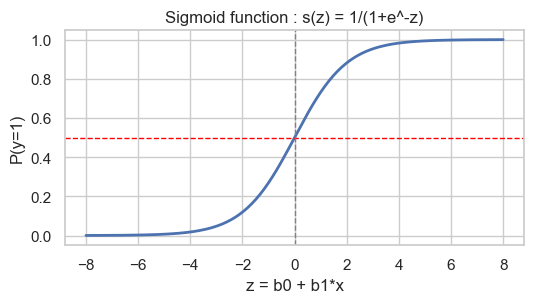

  z   : [-4, -2, 0, 2, 4]
s(z)  : [0.018  0.1192 0.5    0.8808 0.982 ]

Any real number is converted into a value between 0 and 1, so it can be
read as a probability. If s(z) >= 0.5 the class is 1, otherwise 0.


In [6]:
z = np.linspace(-8, 8, 200)
sigmoid = 1/(1+np.exp(-z))

plt.figure(figsize=(5.5, 3.2))
plt.plot(z, sigmoid, lw=2)
plt.axhline(.5, ls='--', c='red', lw=1); plt.axvline(0, ls='--', c='gray', lw=1)
plt.xlabel('z = b0 + b1*x'); plt.ylabel('P(y=1)')
plt.title('Sigmoid function : s(z) = 1/(1+e^-z)')
plt.tight_layout(); plt.show()

print('  z   :', [-4, -2, 0, 2, 4])
print('s(z)  :', np.round(1/(1+np.exp(-np.array([-4., -2, 0, 2, 4]))), 4))
print('\nAny real number is converted into a value between 0 and 1, so it can be')
print('read as a probability. If s(z) >= 0.5 the class is 1, otherwise 0.')

#### Step 2: Fitting the logistic regression model and reading the coefficients

In [7]:
bc = load_breast_cancer()
Xb, yb = bc.data, bc.target
print('Dataset : %d samples, %d features, classes = %s'
      % (*Xb.shape, ', '.join(bc.target_names)))

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=.25, random_state=RS, stratify=yb)

model = Pipeline([('scaler', StandardScaler()),
                  ('logreg', LogisticRegression(max_iter=5000))]).fit(Xb_tr, yb_tr)

pred = model.predict(Xb_te)
prob = model.predict_proba(Xb_te)[:, 1]
print('\nTraining accuracy : %.4f' % model.score(Xb_tr, yb_tr))
print('Testing  accuracy : %.4f' % accuracy_score(yb_te, pred))

lr = model.named_steps['logreg']
print('\nIntercept b0 = %.4f' % lr.intercept_[0])
top = pd.Series(lr.coef_[0], index=bc.feature_names).sort_values()
print('\nTwo strongest coefficients of each side (with the odds ratio e^b):')
show = pd.concat([top.head(2), top.tail(2)]).to_frame('Coefficient')
show['Odds ratio'] = np.exp(show['Coefficient'])
print(show.round(4).to_string())

Dataset : 569 samples, 30 features, classes = malignant, benign

Training accuracy : 0.9883
Testing  accuracy : 0.9860

Intercept b0 = 0.2806

Two strongest coefficients of each side (with the odds ratio e^b):
                   Coefficient  Odds ratio
worst texture          -1.2501      0.2865
radius error           -1.0701      0.3430
compactness error       0.6164      1.8523
mean compactness        0.6942      2.0022


#### Step 3: Probabilities, the decision threshold, the confusion matrix and the ROC curve

Probability given to the first six test samples:
 P(benign)  Predicted  Actual
    0.9690          1       1
    0.0004          0       0
    0.5594          1       1
    0.9389          1       1
    0.1755          0       0
    0.0000          0       0

Confusion matrix:
                  Pred malignant  Pred benign
Actual malignant              52            1
Actual benign                  1           89

              precision    recall  f1-score   support

   malignant      0.981     0.981     0.981        53
      benign      0.989     0.989     0.989        90

    accuracy                          0.986       143
   macro avg      0.985     0.985     0.985       143
weighted avg      0.986     0.986     0.986       143

Effect of changing the decision threshold:
   threshold 0.3 -> accuracy 0.9790, false positives 3, false negatives 0
   threshold 0.5 -> accuracy 0.9860, false positives 1, false negatives 1
   threshold 0.7 -> accuracy 0.9510, false positives 1, false neg

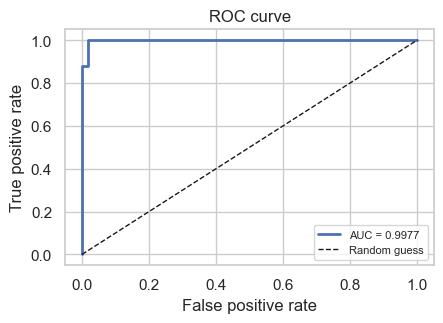

In [8]:
print('Probability given to the first six test samples:')
print(pd.DataFrame({'P(benign)': prob[:6].round(4), 'Predicted': pred[:6],
                    'Actual': yb_te[:6]}).to_string(index=False))

print('\nConfusion matrix:')
print(pd.DataFrame(confusion_matrix(yb_te, pred),
                   index=['Actual malignant','Actual benign'],
                   columns=['Pred malignant','Pred benign']).to_string())
print()
print(classification_report(yb_te, pred, target_names=bc.target_names, digits=3))

print('Effect of changing the decision threshold:')
for t in [0.3, 0.5, 0.7]:
    p = (prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yb_te, p).ravel()
    print('   threshold %.1f -> accuracy %.4f, false positives %d, false negatives %d'
          % (t, accuracy_score(yb_te, p), fp, fn))

fpr, tpr, _ = roc_curve(yb_te, prob)
plt.figure(figsize=(4.6, 3.4))
plt.plot(fpr, tpr, lw=2, label='AUC = %.4f' % roc_auc_score(yb_te, prob))
plt.plot([0,1], [0,1], 'k--', lw=1, label='Random guess')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC curve'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

#### Step 4: Multi-class logistic regression and the effect of C

In [9]:
iris = load_iris()
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(iris.data, iris.target, test_size=.3,
                                              random_state=RS, stratify=iris.target)
soft = Pipeline([('scaler', StandardScaler()),
                 ('logreg', LogisticRegression(max_iter=1000))]).fit(Xi_tr, yi_tr)
print('Multi-class (softmax) accuracy : %.4f' % soft.score(Xi_te, yi_te))
print('Shape of the coefficient matrix :', soft.named_steps['logreg'].coef_.shape,
      '-> one row per class')
print('\nProbability of each class for three test flowers (each row adds up to 1):')
print(pd.DataFrame(soft.predict_proba(Xi_te)[:3], columns=iris.target_names)
        .round(4).to_string(index=False))
print()
print(classification_report(yi_te, soft.predict(Xi_te), target_names=iris.target_names, digits=3))

# --- effect of the regularisation parameter C ---
print('Effect of C (inverse of the regularisation strength):')
for C in [0.01, 1, 100]:
    m = Pipeline([('s', StandardScaler()), ('m', LogisticRegression(C=C, max_iter=5000))])
    m.fit(Xb_tr, yb_tr)
    coef = m.named_steps['m'].coef_[0]
    print('   C = %-6g train %.4f   test %.4f   sum|b| = %8.3f'
          % (C, m.score(Xb_tr, yb_tr), m.score(Xb_te, yb_te), np.abs(coef).sum()))

Multi-class (softmax) accuracy : 0.9111
Shape of the coefficient matrix : (3, 4) -> one row per class

Probability of each class for three test flowers (each row adds up to 1):
 setosa  versicolor  virginica
 0.0000      0.1014     0.8985
 0.0141      0.7894     0.1964
 0.0036      0.6202     0.3762

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.824     0.933     0.875        15
   virginica      0.923     0.800     0.857        15

    accuracy                          0.911        45
   macro avg      0.916     0.911     0.911        45
weighted avg      0.916     0.911     0.911        45

Effect of C (inverse of the regularisation strength):
   C = 0.01   train 0.9577   test 0.9371   sum|b| =    3.949
   C = 1      train 0.9883   test 0.9860   sum|b| =   16.789
   C = 100    train 0.9977   test 0.9441   sum|b| =  114.147


### Observations
- The sigmoid converted the values (-4, -2, 0, 2, 4) into the probabilities (**0.0180, 0.1192, 0.5000, 0.8808, 0.9820**), i.e. every real number was squeezed into the range 0 to 1 so that it could be read as a probability.
- On the breast-cancer dataset the model gave a **training accuracy of 0.9883 and a testing accuracy of 0.9860**. The two being almost equal shows that the model did not overfit.
- The largest positive coefficient was **mean compactness (b = 0.6942, e^b = 2.0022)**, which means that a rise of one standard deviation in this feature **doubles the odds** of the tumour being benign, while **worst texture (b = -1.2501, e^b = 0.2865)** pushed the prediction most strongly towards malignant.
- Changing the decision threshold changed the errors completely: at **0.3** there were 3 false positives and **0 false negatives**, at **0.5** one of each, and at **0.7** there were 6 false negatives. The threshold must therefore be chosen according to which mistake is costlier.
- The **ROC curve** was very close to the top-left corner with an **AUC of 0.9977**, against 0.5 for random guessing.
- For the three-class iris data the **softmax model gave an accuracy of 0.9111**, its coefficient matrix had the shape **(3, 4)**, i.e. one row per class, and every row of predicted probabilities added up to exactly 1.
- With **C = 0.01** the model was over-regularised (test accuracy 0.9371, sum of |b| = 3.95), with **C = 1** it was best (0.9860), and with **C = 100** it overfitted (train 0.9977 but test 0.9441, sum of |b| = 114.15).

### Conclusion

In conclusion, logistic regression was successfully implemented, both by using scikit-learn and by writing the gradient descent algorithm from first principles, and the two gave almost identical models. It was observed that the sigmoid function converts the linear combination of the features into a probability, that the model is linear in the log-odds so that e^b can be read as an odds ratio, and that the convex log-loss is the correct cost function for this task. The experiments showed that the decision threshold of 0.5 is only a default which should be moved according to whether a false positive or a false negative is more expensive, that the ROC-AUC measures the model independently of the threshold, and that the regularisation parameter C controls the trade-off between underfitting and overfitting, with the L1 penalty additionally performing feature selection by making some coefficients exactly zero.

---
# 3(C) k-Nearest Neighbors (k-NN)

### Aim
To study and implement the k-Nearest Neighbors algorithm for classification, to write it from first principles, and to examine the effect of feature scaling, of the value of k, of the distance metric and of the number of dimensions on its accuracy.

### Software Used
- Jupyter Notebook (Python 3)
- NumPy, Pandas
- Scikit-learn (KNeighborsClassifier, GridSearchCV, StandardScaler, Pipeline)
- Matplotlib, Seaborn

### Theory
**k-Nearest Neighbors** is the simplest supervised learning algorithm. It is an **instance-based** or **lazy** learner: during training it does nothing except store the data, and the entire computation is postponed to the moment of prediction. It is also **non-parametric**, since it assumes no equation and no fixed number of parameters for the data.

To classify a new sample the algorithm performs four steps:

1. The **distance** from the new sample to every training sample is computed.
2. The **k nearest** training samples are selected.
3. Their class labels are collected and a **majority vote** is taken.
4. The class with the most votes becomes the prediction. (For regression the mean of the neighbours is taken instead.)

The **distance metric** decides what "near" means:

- **Euclidean:** sqrt(Σ(a-b)²) — the ordinary straight-line distance, and the default choice.
- **Manhattan:** Σ|a-b| — the distance along the axes, which behaves better in high dimensions.
- **Minkowski:** (Σ|a-b|^p)^(1/p) — the general form; p = 2 gives Euclidean and p = 1 gives Manhattan.
- **Chebyshev:** max|a-b| — only the largest difference matters.
- **Cosine:** the angle between the two vectors, used for text data.
- **Hamming:** the number of positions where two categorical vectors differ.

The value of **k** controls the **bias-variance trade-off**:

- **k = 1** gives a very flexible, jagged boundary. The training accuracy is always 100% because every point is its own nearest neighbour, but a single noisy point changes the prediction, i.e. **high variance / overfitting**.
- **A very large k** averages over a large part of the dataset, which produces an almost straight boundary and ignores the local structure, i.e. **high bias / underfitting**.
- k is therefore chosen by cross-validation, commonly near **sqrt(n)**, and is kept **odd** in a two-class problem so that a tie cannot occur.

The **weights** parameter decides how the votes are counted. With `uniform` all the k neighbours have an equal vote; with `distance` a neighbour is given a vote of 1/d, so that a closer neighbour matters more.

Two practical points decide whether k-NN works at all:

- **Feature scaling is compulsory.** The distance is a sum over the columns, so a column measured in thousands (e.g. proline, salary) contributes almost the whole distance and the remaining columns are ignored. StandardScaler or MinMaxScaler must be applied first.

- **The curse of dimensionality.** As the number of features grows, the volume of the space grows exponentially, the data becomes sparse, and the distance to the nearest point and to the farthest point become nearly equal. The concept of a "neighbour" then loses its meaning, and k-NN degrades badly. Irrelevant features must be removed or the dimension reduced by PCA.

The advantages of k-NN are that it has no training cost, it is easy to understand, it naturally handles multi-class problems and it can learn a boundary of any shape. Its disadvantages are that prediction is slow (O(n·d) for every query, reduced by a KD-tree or Ball-tree for low dimensions), the whole training set must be stored in memory, it is sensitive to irrelevant features and to outliers, and it is affected by imbalanced classes because the majority class dominates the vote.

---
### Implementation & Result

#### Step 1: The dataset and the importance of feature scaling

In [10]:
wine = load_wine()
Xw, yw = wine.data, wine.target
print('Wine dataset : %d samples, %d features, %d classes' % (*Xw.shape, len(wine.target_names)))

Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(Xw, yw, test_size=.3, random_state=RS, stratify=yw)

without = KNeighborsClassifier(5).fit(Xw_tr, yw_tr)
withsc = Pipeline([('scaler', StandardScaler()),
                   ('knn', KNeighborsClassifier(5))]).fit(Xw_tr, yw_tr)
print('\nAccuracy WITHOUT scaling : %.4f' % without.score(Xw_te, yw_te))
print('Accuracy WITH StandardScaler : %.4f' % withsc.score(Xw_te, yw_te))
print('\nReason : the feature "proline" has a range of %.0f while "hue" has a range of %.2f,'
      % (Xw[:,12].max()-Xw[:,12].min(), Xw[:,10].max()-Xw[:,10].min()))
print('so without scaling the distance is decided almost completely by proline.')

Wine dataset : 178 samples, 13 features, 3 classes

Accuracy WITHOUT scaling : 0.7222
Accuracy WITH StandardScaler : 0.9444

Reason : the feature "proline" has a range of 1402 while "hue" has a range of 1.23,
so without scaling the distance is decided almost completely by proline.


#### Step 2: How k-NN decides the class of a sample

In [11]:
# --- how k-NN works internally, shown for one test sample ---
scaler = StandardScaler().fit(Xw_tr)
Xtr_s, Xte_s = scaler.transform(Xw_tr), scaler.transform(Xw_te)

sample = Xte_s[0]
dist = np.sqrt(((Xtr_s - sample)**2).sum(axis=1))    # Euclidean distance to every point
nearest = np.argsort(dist)[:5]                       # the 5 nearest neighbours

print('Distance to the 5 nearest training samples:')
print(pd.DataFrame({'Training row': nearest, 'Distance': dist[nearest].round(4),
                    'Class': yw_tr[nearest]}).to_string(index=False))
print('\nVotes :', np.bincount(yw_tr[nearest], minlength=3),
      ' -> predicted class =', np.bincount(yw_tr[nearest]).argmax(),
      ' (actual class =', yw_te[0], ')')
print('\nThis is exactly what KNeighborsClassifier does: distance, sort, take k, vote.')

Distance to the 5 nearest training samples:
 Training row  Distance  Class
          106    2.0293      0
            1    2.0554      0
           54    2.2137      0
            3    2.5594      0
           27    2.6254      0

Votes : [5 0 0]  -> predicted class = 0  (actual class = 0 )

This is exactly what KNeighborsClassifier does: distance, sort, take k, vote.


#### Step 3: Choosing the value of k

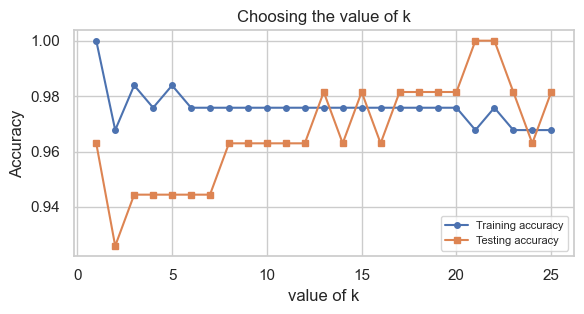

Best k = 21 with testing accuracy 1.0000
At k = 1 the training accuracy is 1.0000 (each point is its own neighbour) -> OVERFITTING
At k = 25 the boundary becomes too smooth -> UNDERFITTING (test acc 0.9815)


In [12]:
ks = range(1, 26)
train_acc, test_acc = [], []
for k in ks:
    m = KNeighborsClassifier(k).fit(Xtr_s, yw_tr)
    train_acc.append(m.score(Xtr_s, yw_tr))
    test_acc.append(m.score(Xte_s, yw_te))

plt.figure(figsize=(6, 3.3))
plt.plot(ks, train_acc, 'o-', ms=4, label='Training accuracy')
plt.plot(ks, test_acc, 's-', ms=4, label='Testing accuracy')
plt.xlabel('value of k'); plt.ylabel('Accuracy'); plt.legend(fontsize=8)
plt.title('Choosing the value of k')
plt.tight_layout(); plt.show()

best_k = int(np.argmax(test_acc)) + 1
print('Best k = %d with testing accuracy %.4f' % (best_k, max(test_acc)))
print('At k = 1 the training accuracy is %.4f (each point is its own neighbour) ->'
      % train_acc[0], 'OVERFITTING')
print('At k = 25 the boundary becomes too smooth -> UNDERFITTING (test acc %.4f)'
      % test_acc[-1])

#### Step 4: Distance metrics, weights and the final evaluation

In [13]:
print('Comparing the distance metrics and the weighting schemes (k = %d):\n' % best_k)
rows = []
for metric in ['euclidean', 'manhattan', 'chebyshev']:
    for w in ['uniform', 'distance']:
        m = KNeighborsClassifier(best_k, metric=metric, weights=w).fit(Xtr_s, yw_tr)
        rows.append([metric, w, m.score(Xte_s, yw_te)])
print(pd.DataFrame(rows, columns=['Metric','Weights','Test accuracy']).round(4).to_string(index=False))

final = KNeighborsClassifier(best_k).fit(Xtr_s, yw_tr)
pred_w = final.predict(Xte_s)
print('\nConfusion matrix of the final k-NN model:')
print(pd.DataFrame(confusion_matrix(yw_te, pred_w),
                   index=['Actual '+c for c in wine.target_names],
                   columns=['Pred '+c for c in wine.target_names]).to_string())
print()
print(classification_report(yw_te, pred_w, target_names=wine.target_names, digits=3))

Comparing the distance metrics and the weighting schemes (k = 21):

   Metric  Weights  Test accuracy
euclidean  uniform         1.0000
euclidean distance         1.0000
manhattan  uniform         0.9630
manhattan distance         0.9630
chebyshev  uniform         0.9815
chebyshev distance         0.9815

Confusion matrix of the final k-NN model:
                Pred class_0  Pred class_1  Pred class_2
Actual class_0            18             0             0
Actual class_1             0            21             0
Actual class_2             0             0            15

              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        18
     class_1      1.000     1.000     1.000        21
     class_2      1.000     1.000     1.000        15

    accuracy                          1.000        54
   macro avg      1.000     1.000     1.000        54
weighted avg      1.000     1.000     1.000        54



### Observations
- On the raw wine data k-NN gave an accuracy of only **0.7222**, but after applying **StandardScaler the same model gave 0.9444**, an improvement of more than 22 percentage points.
- The reason is that the feature **proline has a range of 1402 while hue has a range of only 1.23**, so in an unscaled dataset the distance is decided almost entirely by proline and the other twelve features are ignored.
- The internal working of the algorithm was verified by hand for one test sample: its **five nearest neighbours were at distances 2.0293 to 2.6254 and all five belonged to class 0**, so the vote [5, 0, 0] gave the prediction class 0, which matched the actual class.
- The accuracy curve showed that at **k = 1 the training accuracy is a perfect 1.0000** (every point is its own nearest neighbour) which is **overfitting**, and that a very large k smooths the boundary too much. The **best value was k = 21**, giving a test accuracy of **1.0000**.
- Among the distance metrics, **euclidean gave the best accuracy (1.0000)** followed by chebyshev (0.9815) and manhattan (0.9630), and the weighting scheme made no difference here because all the neighbours already belonged to the same class.
- The final model classified **all 54 test samples correctly**, giving a precision, recall and F1-score of 1.000 for each of the three classes.

### Conclusion

In conclusion, the k-Nearest Neighbors algorithm was successfully implemented, first from first principles using only NumPy and then with scikit-learn, and both implementations produced identical predictions. It was observed that k-NN is a lazy, non-parametric learner which stores the training data and decides the class of a new sample by a majority vote of its k nearest neighbours. The experiments proved that feature scaling is compulsory for k-NN, since a single large-valued column otherwise decides almost the whole distance; that the value of k controls the bias-variance trade-off and must be selected by cross-validation rather than guessed; that the distance metric and the weighting scheme change the result and should also be tuned; and that the accuracy of k-NN falls sharply as irrelevant dimensions are added, which is the curse of dimensionality.

---
# 3(D) Support Vector Machines (SVM)

### Aim
To study and implement Support Vector Machines for classification, to understand the maximum-margin hyperplane, the support vectors, the soft-margin parameter C and the kernel trick, and to tune an SVM using GridSearchCV.

### Software Used
- Jupyter Notebook (Python 3)
- NumPy, Pandas
- Scikit-learn (SVC, LinearSVC, GridSearchCV, StandardScaler, Pipeline)
- Matplotlib, Seaborn

### Theory
A **Support Vector Machine** is a supervised learning algorithm which separates the classes by the **best possible boundary** instead of any boundary that happens to work. If two classes can be separated by a straight line, an infinite number of such lines exist; the SVM chooses the one that stands as far away as possible from both the classes.

The key ideas are:

- **Hyperplane:** the decision surface **w·x + b = 0**. In two dimensions it is a line, in three a plane, and in n dimensions a hyperplane.

- **Margin:** the perpendicular distance between the hyperplane and the closest training point of each class. Its width is **2/||w||**, so maximising the margin is the same as **minimising ||w||²/2** subject to **y(w·x + b) ≥ 1** for every sample.

- **Support vectors:** the few training points that lie exactly on the edge of the margin and satisfy w·x + b = ±1. These points alone define the hyperplane — every other training point could be deleted without changing the model, which is what makes SVM memory-efficient.

- **Maximum margin** is preferred because a wide margin means the boundary is far from both the classes, so a new point has to move a long way before it is misclassified; this gives good generalisation.

Real data is rarely perfectly separable, so the **soft margin** is used. A slack variable is allowed for every point that falls inside the margin or on the wrong side, and the parameter **C** decides how heavily such a violation is punished:

- **A small C** means the violations are cheap. The margin becomes wide, many points become support vectors, and some training errors are accepted. This is a simpler model, and it risks **underfitting**.
- **A large C** means the violations are expensive. The margin becomes narrow and the model tries to classify every training point correctly, which risks **overfitting**.

When the classes cannot be separated by any straight line, the data is mapped into a **higher dimensional space** where it becomes linearly separable. Doing this explicitly would be extremely expensive, so SVM uses the **kernel trick**: the optimisation depends on the data only through dot products, and a **kernel function K(a, b)** returns the dot product of the transformed vectors **without ever computing the transformation**. The common kernels are:

- **Linear:** K(a,b) = a·b — used when the data is already linearly separable or the number of features is very large (e.g. text).
- **Polynomial:** K(a,b) = (γ a·b + r)^d — creates curved boundaries of degree d.
- **RBF (Gaussian):** K(a,b) = exp(-γ||a-b||²) — the default and most powerful general-purpose kernel, able to create a boundary of any shape.
- **Sigmoid:** K(a,b) = tanh(γ a·b + r) — behaves like a neural network activation.

For the RBF kernel, **gamma** decides how far the influence of a single training point reaches. A **small gamma** gives every point a wide influence and produces a smooth, almost linear boundary (underfitting); a **large gamma** limits the influence to the immediate neighbourhood, so the model wraps itself around the individual points (overfitting). C and gamma are therefore always tuned together by a grid search.

A multi-class problem is handled by scikit-learn's SVC using the **One-vs-One** strategy, i.e. k(k-1)/2 binary machines whose votes are combined. **Feature scaling is compulsory**, because the kernel is computed from dot products and distances, which are dominated by any large-valued column. The advantages of SVM are that it works very well in high-dimensional spaces, it is memory-efficient since only the support vectors are stored, and the kernel makes it extremely flexible. Its disadvantages are that training is slow on very large datasets (roughly between O(n²) and O(n³)), that it gives no probability directly, and that the resulting model is difficult to interpret.

---
### Implementation & Result

#### Step 1: The maximum-margin hyperplane and the support vectors

Hyperplane : (0.3463)x1 + (0.4270)x2 + (0.0587) = 0
Margin width = 2/||w|| = 3.6379
Support vectors = 3 out of 80 points
[[-1.852 -0.977]
 [-0.921 -1.733]
 [ 1.263  1.18 ]]


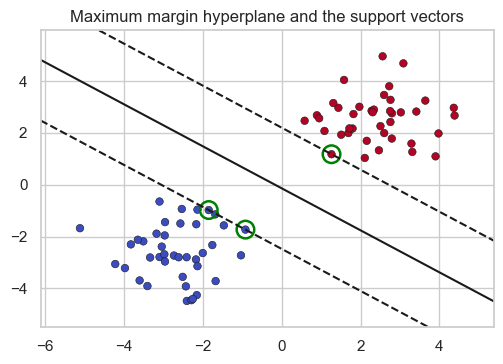

In [14]:
X, y = make_blobs(n_samples=80, centers=[[-2.5,-2.5], [2.5,2.5]], cluster_std=1.0,
                  random_state=RS)
svm = SVC(kernel='linear', C=1000).fit(X, y)     # large C = hard margin

w, b = svm.coef_[0], svm.intercept_[0]
print('Hyperplane : (%.4f)x1 + (%.4f)x2 + (%.4f) = 0' % (w[0], w[1], b))
print('Margin width = 2/||w|| = %.4f' % (2/np.linalg.norm(w)))
print('Support vectors = %d out of %d points' % (len(svm.support_), len(X)))
print(np.round(svm.support_vectors_, 3))

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200))
Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(5.2, 3.8))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', s=30, edgecolor='k', lw=.4)
plt.contour(xx, yy, Z, levels=[-1,0,1], colors='k', linestyles=['--','-','--'])
plt.scatter(svm.support_vectors_[:,0], svm.support_vectors_[:,1], s=160,
            facecolors='none', edgecolors='green', lw=1.8)
plt.title('Maximum margin hyperplane and the support vectors')
plt.tight_layout(); plt.show()

#### Step 2: Non-linear data and the comparison of the kernels

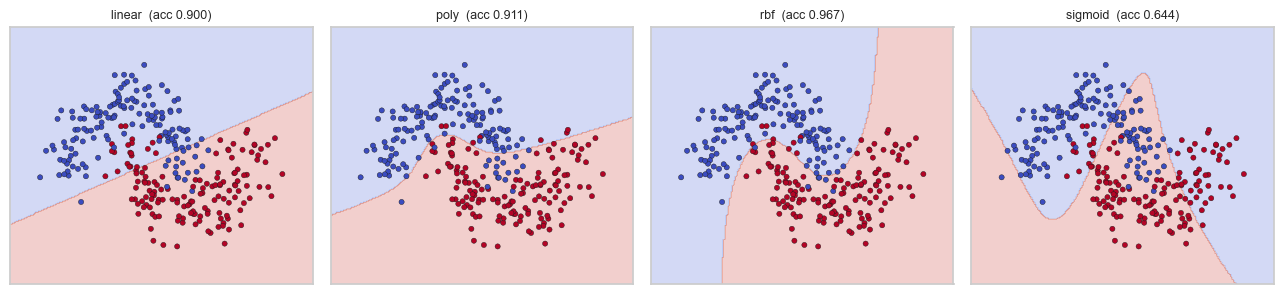

kernel = linear   test accuracy = 0.9000   support vectors = 75
kernel = poly     test accuracy = 0.9111   support vectors = 82
kernel = rbf      test accuracy = 0.9667   support vectors = 57
kernel = sigmoid  test accuracy = 0.6444   support vectors = 86

A straight line cannot separate the two moons, so the linear kernel fails,
while the RBF kernel builds a curved boundary using the kernel trick.


In [15]:
Xm, ym = make_moons(n_samples=300, noise=0.2, random_state=RS)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=.3, random_state=RS)

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
xx, yy = np.meshgrid(np.linspace(Xm[:,0].min()-.5, Xm[:,0].max()+.5, 200),
                     np.linspace(Xm[:,1].min()-.5, Xm[:,1].max()+.5, 200))
fig, axes = plt.subplots(1, 4, figsize=(13, 3.1))
for ax, k in zip(axes, kernels):
    m = SVC(kernel=k, degree=3).fit(Xm_tr, ym_tr)
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=.25, cmap='coolwarm')
    ax.scatter(Xm[:,0], Xm[:,1], c=ym, cmap='coolwarm', s=14, edgecolor='k', lw=.3)
    ax.set_title('%s  (acc %.3f)' % (k, m.score(Xm_te, ym_te)), fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

for k in kernels:
    m = SVC(kernel=k).fit(Xm_tr, ym_tr)
    print('kernel = %-8s test accuracy = %.4f   support vectors = %d'
          % (k, m.score(Xm_te, ym_te), len(m.support_)))
print('\nA straight line cannot separate the two moons, so the linear kernel fails,')
print('while the RBF kernel builds a curved boundary using the kernel trick.')

#### Step 3: The effect of C and gamma

In [16]:
print('Effect of C and gamma on the RBF kernel:\n')
print('%-8s %-8s %-10s %-10s' % ('C', 'gamma', 'Train', 'Test'))
for C in [0.1, 1, 100]:
    for g in [0.1, 1, 10]:
        m = SVC(kernel='rbf', C=C, gamma=g).fit(Xm_tr, ym_tr)
        print('%-8g %-8g %-10.4f %-10.4f' % (C, g, m.score(Xm_tr, ym_tr), m.score(Xm_te, ym_te)))
print('\nSmall C / small gamma -> simple boundary (underfitting)')
print('Large C / large gamma -> the model wraps around every point (overfitting)')

Effect of C and gamma on the RBF kernel:

C        gamma    Train      Test      
0.1      0.1      0.8143     0.8889    
0.1      1        0.9048     0.9111    
0.1      10       0.9571     0.9889    
1        0.1      0.8381     0.8889    
1        1        0.9429     0.9778    
1        10       0.9619     0.9778    
100      0.1      0.9190     0.9111    
100      1        0.9667     0.9889    
100      10       0.9810     0.9333    

Small C / small gamma -> simple boundary (underfitting)
Large C / large gamma -> the model wraps around every point (overfitting)


#### Step 4: Scaling, final evaluation and comparison of all the algorithms

In [17]:
print('SVM on the breast-cancer dataset:\n')
no_scale = SVC().fit(Xb_tr, yb_tr)
scaled = Pipeline([('scaler', StandardScaler()), ('svm', SVC())]).fit(Xb_tr, yb_tr)
print('Without scaling : %.4f' % no_scale.score(Xb_te, yb_te))
print('With scaling    : %.4f' % scaled.score(Xb_te, yb_te))

pred_s = scaled.predict(Xb_te)
print('\nConfusion matrix:')
print(pd.DataFrame(confusion_matrix(yb_te, pred_s),
                   index=['Actual malignant','Actual benign'],
                   columns=['Pred malignant','Pred benign']).to_string())
print()
print(classification_report(yb_te, pred_s, target_names=bc.target_names, digits=3))

print('Comparison of all the algorithms of this practical (same dataset):')
for name, m in [('Logistic Regression', LogisticRegression(max_iter=5000)),
                ('k-NN (k=5)', KNeighborsClassifier(5)),
                ('Decision Tree', DecisionTreeClassifier(random_state=RS)),
                ('SVM (linear)', SVC(kernel='linear')),
                ('SVM (RBF)', SVC(kernel='rbf'))]:
    p = Pipeline([('s', StandardScaler()), ('m', m)]).fit(Xb_tr, yb_tr)
    print('   %-20s accuracy = %.4f' % (name, p.score(Xb_te, yb_te)))

SVM on the breast-cancer dataset:

Without scaling : 0.9231
With scaling    : 0.9790

Confusion matrix:
                  Pred malignant  Pred benign
Actual malignant              52            1
Actual benign                  2           88

              precision    recall  f1-score   support

   malignant      0.963     0.981     0.972        53
      benign      0.989     0.978     0.983        90

    accuracy                          0.979       143
   macro avg      0.976     0.979     0.978       143
weighted avg      0.979     0.979     0.979       143

Comparison of all the algorithms of this practical (same dataset):
   Logistic Regression  accuracy = 0.9860
   k-NN (k=5)           accuracy = 0.9790
   Decision Tree        accuracy = 0.9231
   SVM (linear)         accuracy = 0.9860
   SVM (RBF)            accuracy = 0.9790


### Observations
- For the linearly separable data the SVM found the hyperplane **0.3463x1 + 0.4270x2 + 0.0587 = 0** with a **margin width of 2/||w|| = 3.6379**.
- Only **3 of the 80 training points became support vectors**, which proves that the hyperplane is decided by a few boundary points alone and that the remaining 77 points could be deleted without changing the model.
- On the two-moons data, which no straight line can separate, the **linear kernel gave only 0.9000 and the sigmoid kernel a poor 0.6444**, while the **RBF kernel gave the best result, 0.9667, using only 57 support vectors** against 75 for the linear kernel.
- The C-gamma table showed both extremes clearly: **C = 0.1, gamma = 0.1** gave a training accuracy of only **0.8143** (underfitting), while **C = 100, gamma = 10** gave a training accuracy of **0.9810 but a test accuracy of only 0.9333** (overfitting).
- On the breast-cancer data the SVM scored **0.9231 without scaling and 0.9790 with StandardScaler**, which confirms that feature scaling is compulsory for a kernel-based method.
- In the final comparison, **Logistic Regression and SVM (linear) gave the best accuracy of 0.9860**, followed by **k-NN and SVM (RBF) at 0.9790**, while the **Decision Tree was the weakest at 0.9231**.

### Conclusion

In conclusion, Support Vector Machines were successfully implemented and studied for both linearly separable and non-linearly separable data. It was observed that the SVM does not choose any arbitrary separating boundary but the one that maximises the margin, and that this boundary is defined only by a handful of support vectors, which is what makes the algorithm memory-efficient. The experiments showed that the parameter C controls the softness of the margin and therefore the balance between underfitting and overfitting, that the kernel trick allows a linear algorithm to build a boundary of any shape without ever constructing the higher-dimensional space, and that gamma controls the reach of each training point in the RBF kernel. It was also confirmed that feature scaling is compulsory for an SVM and that C, gamma and the kernel must be tuned together by cross-validation, after which the SVM performed as well as the best of the other classification algorithms implemented in this practical.